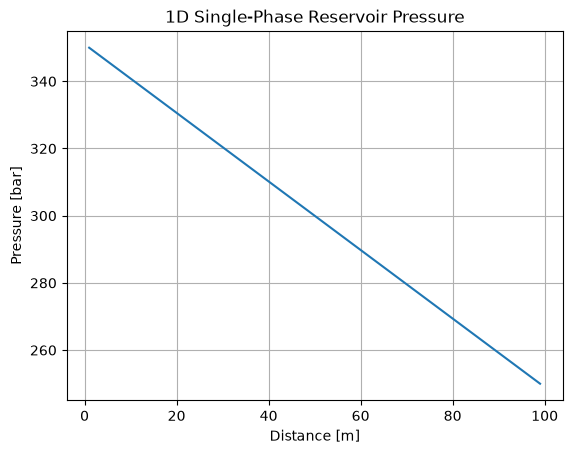

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Reservoir properties
# -----------------------------
L = 100.0          # reservoir length [m]
N = 50             # number of cells
dx = L / N
A_cross = 1.0      # cross-sectional area [m^2]

phi = 0.20         # porosity
ct = 1e-9          # total compressibility [1/Pa]
k = 100 * 9.869e-16  # 100 mD -> m^2
mu = 1e-3          # viscosity [Pa.s]

# -----------------------------
# Time properties
# -----------------------------
dt = 1 * 86400     # 1 day [s]
n_steps = 100

# -----------------------------
# Boundary conditions
# -----------------------------
p_left = 350e5     # 350 bar [Pa]
p_right = 250e5    # 250 bar [Pa]

# Initial pressure
p = np.ones(N) * 300e5   # 300 bar

# -----------------------------
# Transmissibility
# -----------------------------
T = k * A_cross / (mu * dx)

# Accumulation coefficient
C = phi * ct * A_cross * dx

# -----------------------------
# Build system matrix
# -----------------------------
M = C / dt

A = np.zeros((N, N))

for i in range(N):

    # Diagonal
    A[i, i] = M + 2 * T

    # Left neighbor
    if i > 0:
        A[i, i - 1] = -T

    # Right neighbor
    if i < N - 1:
        A[i, i + 1] = -T


# -----------------------------
# Time stepping
# -----------------------------

pressure_history = []
for step in range(n_steps):

    b = M * p.copy()

    # Dirichlet BC: left boundary
    A[0, :] = 0
    A[0, 0] = 1
    b[0] = p_left

    # Dirichlet BC: right boundary
    A[-1, :] = 0
    A[-1, -1] = 1
    b[-1] = p_right

    # Solve
    p = np.linalg.solve(A, b)
    pressure_history.append(p.copy())

# -----------------------------
# Plot pressure
# -----------------------------
x = np.linspace(dx / 2, L - dx / 2, N)

plt.plot(x, p / 1e5)
plt.xlabel("Distance [m]")
plt.ylabel("Pressure [bar]")
plt.title("1D Single-Phase Reservoir Pressure")
plt.grid()
plt.show()

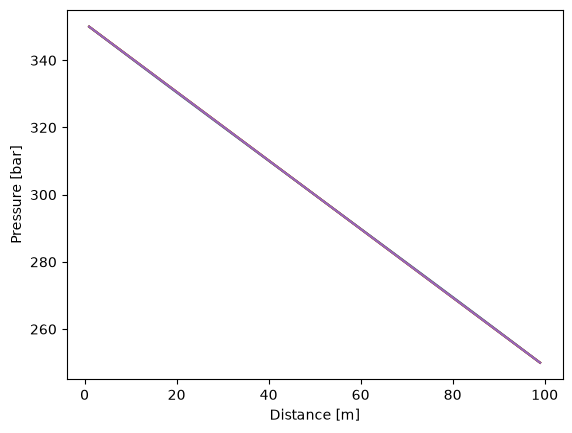

In [3]:
for p_snapshot in pressure_history[::20]:
    plt.plot(x, p_snapshot / 1e5)

plt.xlabel("Distance [m]")
plt.ylabel("Pressure [bar]")
plt.show()

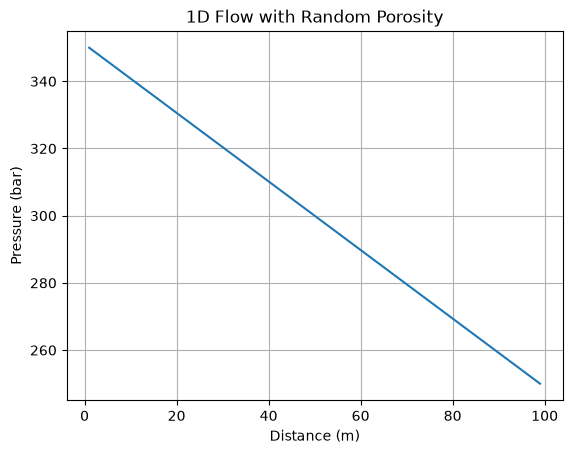

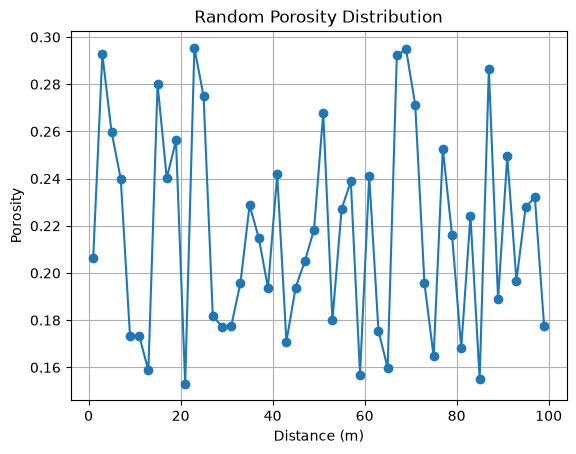

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Reservoir
# -----------------------------
L = 100.0
N = 50
dx = L / N
A_cross = 1.0

np.random.seed(42)

# Random porosity for each cell
phi = np.random.uniform(0.15, 0.30, N)

# Constant permeability
k = 100 * 9.869e-16   # 100 mD -> mÂ²
mu = 1e-3             # Pa.s
ct = 1e-9             # 1/Pa

# -----------------------------
# Time
# -----------------------------
dt = 86400            # 1 day
n_steps = 100

# -----------------------------
# Boundary conditions
# -----------------------------
p_left = 350e5        # 350 bar
p_right = 250e5       # 250 bar

p = np.ones(N) * 300e5

# -----------------------------
# Transmissibility
# k is constant
# -----------------------------
T = k * A_cross / (mu * dx)

# -----------------------------
# Time stepping
# -----------------------------
pressure_history = []

for step in range(n_steps):

    A = np.zeros((N, N))
    b = np.zeros(N)

    for i in range(N):

        # Accumulation depends on local porosity
        C = phi[i] * ct * A_cross * dx
        M = C / dt

        A[i, i] = M + 2 * T
        b[i] = M * p[i]

        if i > 0:
            A[i, i - 1] = -T

        if i < N - 1:
            A[i, i + 1] = -T

    # Left boundary
    A[0, :] = 0
    A[0, 0] = 1
    b[0] = p_left

    # Right boundary
    A[-1, :] = 0
    A[-1, -1] = 1
    b[-1] = p_right

    # Solve
    p = np.linalg.solve(A, b)

    pressure_history.append(p.copy())

# -----------------------------
# Plot pressure
# -----------------------------
x = np.linspace(dx / 2, L - dx / 2, N)

plt.plot(x, p / 1e5)
plt.xlabel("Distance (m)")
plt.ylabel("Pressure (bar)")
plt.title("1D Flow with Random Porosity")
plt.grid()
plt.show()

# Plot porosity
plt.plot(x, phi, marker="o")
plt.xlabel("Distance (m)")
plt.ylabel("Porosity")
plt.title("Random Porosity Distribution")
plt.grid()
plt.show()

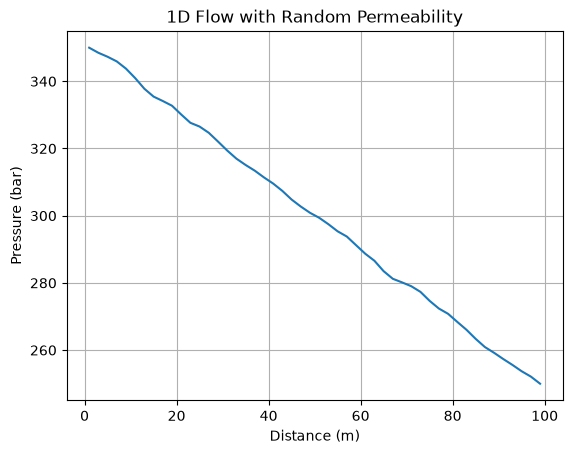

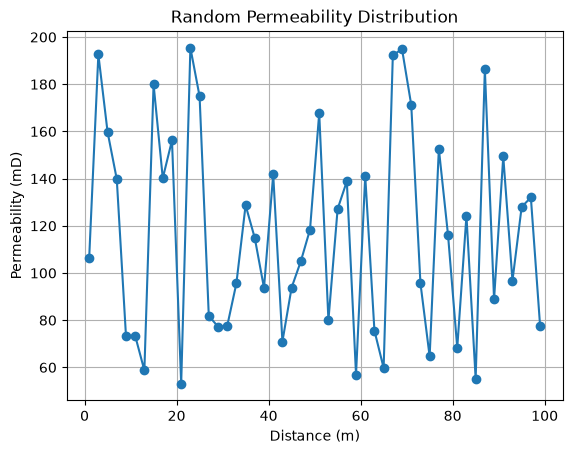

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Reservoir
# -----------------------------
L = 100.0
N = 50
dx = L / N
A_cross = 1.0

np.random.seed(42)

# Constant porosity
phi = 0.20

# Random permeability
k_md = np.random.uniform(50, 200, N)

# Convert mD -> mÂ²
k = k_md * 9.869e-16

mu = 1e-3
ct = 1e-9

# -----------------------------
# Time
# -----------------------------
dt = 86400
n_steps = 100

# -----------------------------
# Boundary conditions
# -----------------------------
p_left = 350e5
p_right = 250e5

p = np.ones(N) * 300e5

# -----------------------------
# Time stepping
# -----------------------------
pressure_history = []

for step in range(n_steps):

    A = np.zeros((N, N))
    b = np.zeros(N)

    # Constant accumulation
    C = phi * ct * A_cross * dx
    M = C / dt

    for i in range(N):

        # -------------------------
        # Transmissibility
        # -------------------------
        if i > 0:
            k_left = 2 * k[i] * k[i - 1] / (k[i] + k[i - 1])
            T_left = k_left * A_cross / (mu * dx)
        else:
            T_left = 0

        if i < N - 1:
            k_right = 2 * k[i] * k[i + 1] / (k[i] + k[i + 1])
            T_right = k_right * A_cross / (mu * dx)
        else:
            T_right = 0

        # -------------------------
        # Matrix
        # -------------------------
        A[i, i] = M + T_left + T_right
        b[i] = M * p[i]

        if i > 0:
            A[i, i - 1] = -T_left

        if i < N - 1:
            A[i, i + 1] = -T_right

    # Left boundary
    A[0, :] = 0
    A[0, 0] = 1
    b[0] = p_left

    # Right boundary
    A[-1, :] = 0
    A[-1, -1] = 1
    b[-1] = p_right

    # Solve
    p = np.linalg.solve(A, b)

    pressure_history.append(p.copy())

# -----------------------------
# Plot pressure
# -----------------------------
x = np.linspace(dx / 2, L - dx / 2, N)

plt.plot(x, p / 1e5)
plt.xlabel("Distance (m)")
plt.ylabel("Pressure (bar)")
plt.title("1D Flow with Random Permeability")
plt.grid()
plt.show()

# Plot permeability
plt.plot(x, k_md, marker="o")
plt.xlabel("Distance (m)")
plt.ylabel("Permeability (mD)")
plt.title("Random Permeability Distribution")
plt.grid()
plt.show()

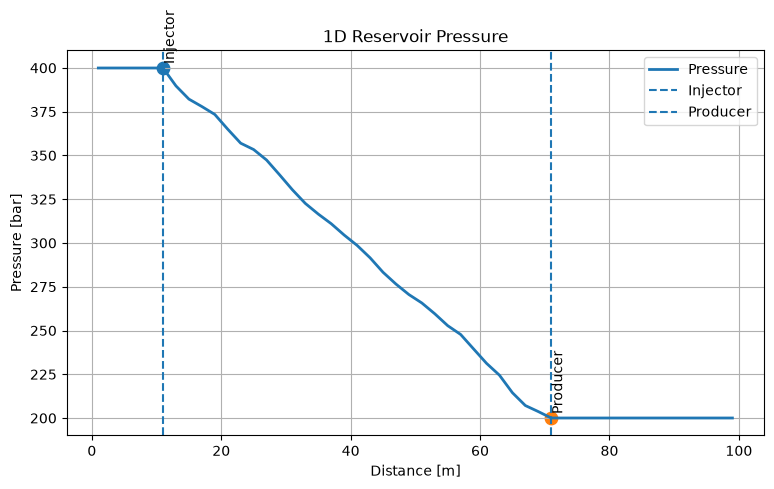

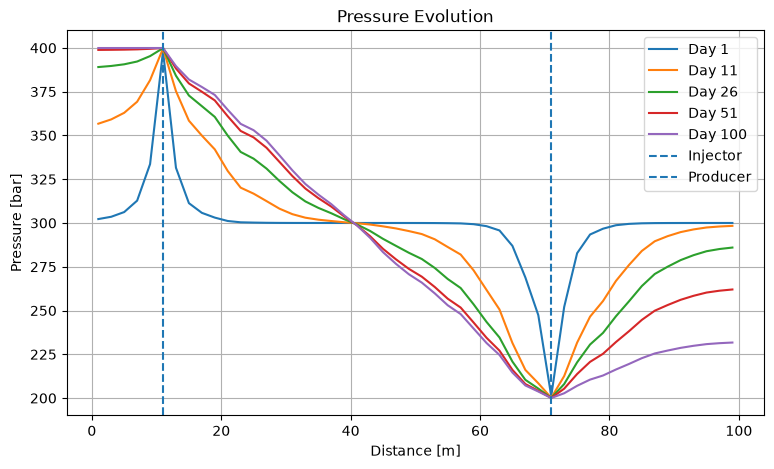

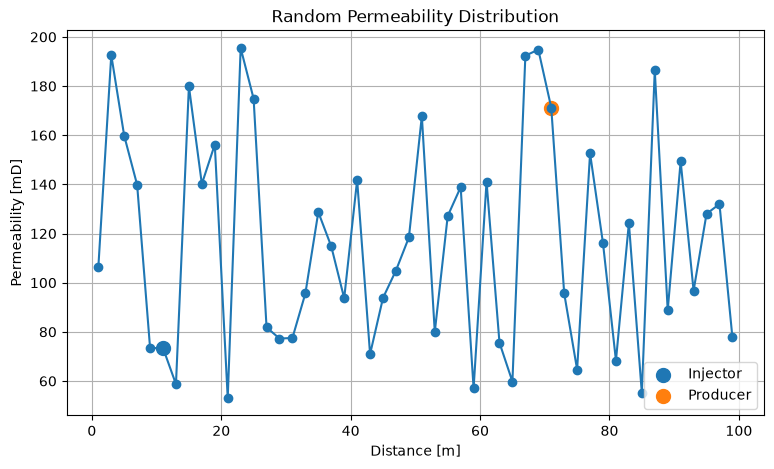

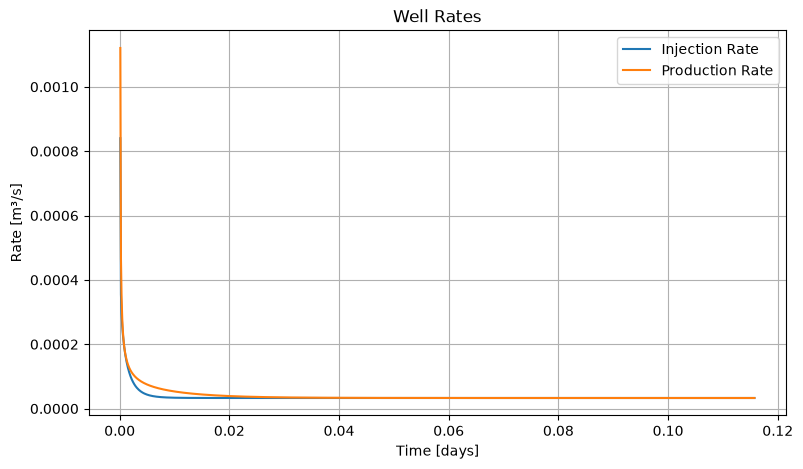

SIMULATION RESULTS
Injector cell       : 5
Injector location   : 11.00 m
Producer cell       : 35
Producer location   : 71.00 m
Injector WI         : 4.4206e-09
Producer WI         : 1.0314e-08
Final injector rate : 3.2940e-05 mÂ³/s
Final producer rate : 3.2940e-05 mÂ³/s
Pressure at injector: 399.93 bar
Pressure at producer: 200.03 bar


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1D SINGLE-PHASE RESERVOIR
# Variable Permeability + Injector + Producer
# Fully Implicit Time Stepping
# ============================================================

# ------------------------------------------------------------
# 1. RESERVOIR PARAMETERS
# ------------------------------------------------------------

L = 100.0                  # Reservoir length [m]
N = 50                     # Number of cells
dx = L / N                 # Cell length [m]

A = 1.0                    # Cross-sectional area [mÂ²]
h = 10.0                   # Reservoir thickness [m]

phi = 0.20                 # Porosity
ct = 1e-9                  # Total compressibility [1/Pa]
mu = 1e-3                  # Fluid viscosity [Pa.s]

# ------------------------------------------------------------
# 2. RANDOM PERMEABILITY
# ------------------------------------------------------------

np.random.seed(42)

# Random permeability in mD
k_md = np.random.uniform(50, 200, N)

# Convert mD -> mÂ²
k = k_md * 9.869233e-16


# ------------------------------------------------------------
# 3. TIME PARAMETERS
# ------------------------------------------------------------

dt = 10             # Timestep = 1 day [s]
n_steps = 1000             # Number of timesteps


# ------------------------------------------------------------
# 4. INITIAL PRESSURE
# ------------------------------------------------------------

p_initial = 300e5          # 300 bar [Pa]

p = np.ones(N) * p_initial


# ============================================================
# 5. WELL PARAMETERS
# ============================================================

# Explicitly define well locations
# Cell indices range from 0 to N-1

injector_cell = 5
producer_cell = 35

# Well radius
rw = 0.1                   # [m]

# Bottom-hole flowing pressures
p_wf_inj = 400e5           # 400 bar
p_wf_prod = 200e5          # 200 bar

# Skin factor
skin = 0.0


# ============================================================
# 6. TRANSMISSIBILITY
# ============================================================

# Transmissibility between neighboring cells
#
# T = k_face * A / (mu * dx)
#
# Harmonic averaging is used because permeability is variable.

T = np.zeros(N - 1)

for i in range(N - 1):

    k_face = (
        2 * k[i] * k[i + 1]
        / (k[i] + k[i + 1])
    )

    T[i] = (
        k_face * A
        / (mu * dx)
    )


# ============================================================
# 7. PEACEMAN WELL INDEX
# ============================================================

def well_index(k_cell, dx, h, rw, mu, skin=0.0):

    # Effective drainage radius
    re = 0.14 * dx

    WI = (
        2 * np.pi * k_cell * h
        /
        (
            mu *
            (np.log(re / rw) + skin)
        )
    )

    return WI


# Well indices use permeability of the cell containing the well

WI_inj = well_index(
    k[injector_cell],
    dx,
    h,
    rw,
    mu,
    skin
)

WI_prod = well_index(
    k[producer_cell],
    dx,
    h,
    rw,
    mu,
    skin
)


# ============================================================
# 8. TIME LOOP
# ============================================================

pressure_history = []

q_inj_history = []
q_prod_history = []

time_history = []


for step in range(n_steps):

    # --------------------------------------------------------
    # Matrix and RHS
    # --------------------------------------------------------

    M = np.zeros((N, N))
    b = np.zeros(N)

    # --------------------------------------------------------
    # Accumulation
    # --------------------------------------------------------

    C = phi * ct * A * dx
    accum = C / dt

    for i in range(N):

        M[i, i] += accum

        b[i] += accum * p[i]


    # --------------------------------------------------------
    # Flow between neighboring cells
    #
    # No-flow boundary conditions are automatically obtained
    # because we only connect cells that actually have neighbors.
    # --------------------------------------------------------

    for i in range(N - 1):

        t = T[i]

        # Diagonal terms
        M[i, i] += t
        M[i + 1, i + 1] += t

        # Off-diagonal terms
        M[i, i + 1] -= t
        M[i + 1, i] -= t


    # ========================================================
    # 9. INJECTOR
    # ========================================================

    # q_inj = WI * (p_wf - p_cell)
    #
    # Positive q = injection into reservoir

    M[injector_cell, injector_cell] += WI_inj

    b[injector_cell] += (
        WI_inj * p_wf_inj
    )


    # ========================================================
    # 10. PRODUCER
    # ========================================================

    # q_prod = WI * (p_wf - p_cell)
    #
    # Since p_wf < p_cell, q_prod is negative.
    # Negative q means fluid is being removed.

    M[producer_cell, producer_cell] += WI_prod

    b[producer_cell] += (
        WI_prod * p_wf_prod
    )


    # ========================================================
    # 11. SOLVE LINEAR SYSTEM
    # ========================================================

    p_new = np.linalg.solve(M, b)


    # ========================================================
    # 12. CALCULATE WELL RATES
    # ========================================================

    q_inj = (
        WI_inj
        * (p_wf_inj - p_new[injector_cell])
    )

    q_prod = (
        WI_prod
        * (p_wf_prod - p_new[producer_cell])
    )


    # --------------------------------------------------------
    # Update pressure
    # --------------------------------------------------------

    p = p_new


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    pressure_history.append(p.copy())

    q_inj_history.append(q_inj)

    q_prod_history.append(q_prod)

    time_history.append(
        (step + 1) * dt / 86400
    )


# ============================================================
# 13. X COORDINATES
# ============================================================

x = np.linspace(
    dx / 2,
    L - dx / 2,
    N
)


# ============================================================
# 14. FINAL PRESSURE PROFILE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    p / 1e5,
    linewidth=2,
    label="Pressure"
)

# Injector
plt.axvline(
    x[injector_cell],
    linestyle="--",
    label="Injector"
)

# Producer
plt.axvline(
    x[producer_cell],
    linestyle="--",
    label="Producer"
)

plt.scatter(
    x[injector_cell],
    p[injector_cell] / 1e5,
    s=80
)

plt.scatter(
    x[producer_cell],
    p[producer_cell] / 1e5,
    s=80
)

plt.text(
    x[injector_cell],
    p[injector_cell] / 1e5,
    " Injector",
    rotation=90,
    verticalalignment="bottom"
)

plt.text(
    x[producer_cell],
    p[producer_cell] / 1e5,
    " Producer",
    rotation=90,
    verticalalignment="bottom"
)

plt.xlabel("Distance [m]")
plt.ylabel("Pressure [bar]")
plt.title("1D Reservoir Pressure")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 15. PRESSURE EVOLUTION
# ============================================================

plt.figure(figsize=(9, 5))

selected_steps = [0, 10, 25, 50, 99]

for step in selected_steps:

    plt.plot(
        x,
        np.array(pressure_history[step]) / 1e5,
        label=f"Day {step + 1}"
    )

# Wells
plt.axvline(
    x[injector_cell],
    linestyle="--",
    label="Injector"
)

plt.axvline(
    x[producer_cell],
    linestyle="--",
    label="Producer"
)

plt.xlabel("Distance [m]")
plt.ylabel("Pressure [bar]")
plt.title("Pressure Evolution")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 16. PERMEABILITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    k_md,
    marker="o"
)

# Mark injector
plt.scatter(
    x[injector_cell],
    k_md[injector_cell],
    s=100,
    label="Injector"
)

# Mark producer
plt.scatter(
    x[producer_cell],
    k_md[producer_cell],
    s=100,
    label="Producer"
)

plt.xlabel("Distance [m]")
plt.ylabel("Permeability [mD]")
plt.title("Random Permeability Distribution")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 17. WELL RATES
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    time_history,
    np.array(q_inj_history),
    label="Injection Rate"
)

# q_prod is negative, so plot -q_prod
plt.plot(
    time_history,
    -np.array(q_prod_history),
    label="Production Rate"
)

plt.xlabel("Time [days]")
plt.ylabel("Rate [mÂ³/s]")
plt.title("Well Rates")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 18. PRINT RESULTS
# ============================================================

print("============================================")
print("SIMULATION RESULTS")
print("============================================")

print(f"Injector cell       : {injector_cell}")
print(f"Injector location   : {x[injector_cell]:.2f} m")

print(f"Producer cell       : {producer_cell}")
print(f"Producer location   : {x[producer_cell]:.2f} m")

print(f"Injector WI         : {WI_inj:.4e}")
print(f"Producer WI         : {WI_prod:.4e}")

print(f"Final injector rate : {q_inj_history[-1]:.4e} mÂ³/s")
print(f"Final producer rate : {-q_prod_history[-1]:.4e} mÂ³/s")

print(
    f"Pressure at injector: "
    f"{p[injector_cell] / 1e5:.2f} bar"
)

print(
    f"Pressure at producer: "
    f"{p[producer_cell] / 1e5:.2f} bar"
)

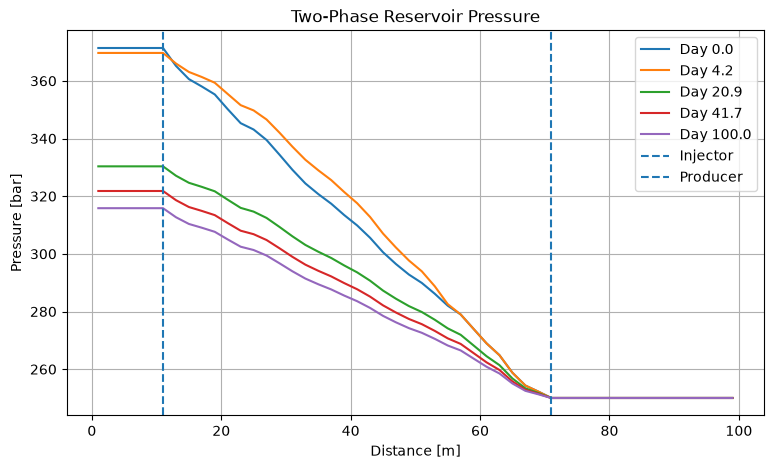

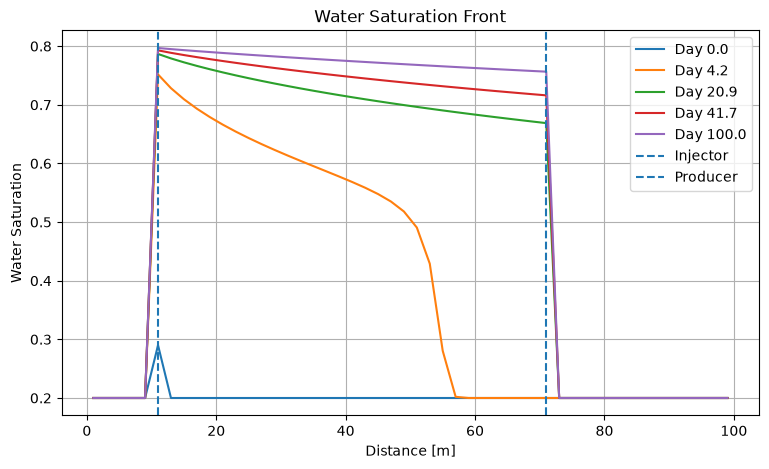

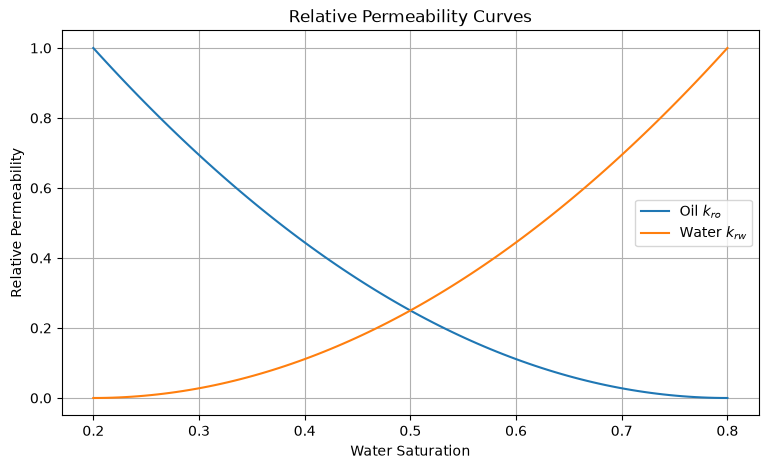

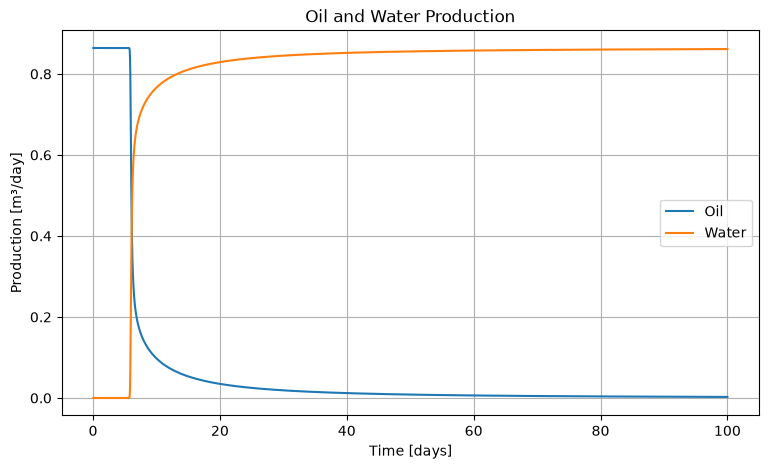

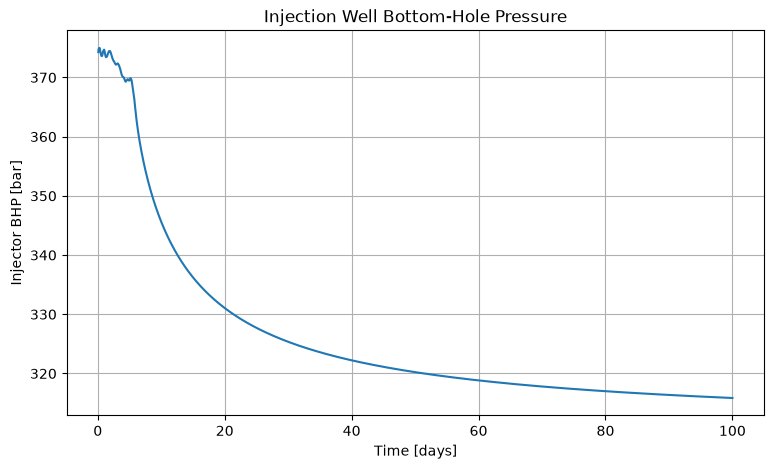

FINAL RESULTS
Injector cell       : 5
Injector location   : 11.00 m
Producer cell       : 35
Producer location   : 71.00 m
Final injector BHP  : 315.86 bar
Final oil rate      : 0.0026 mÂ³/day
Final water rate    : 0.8614 mÂ³/day
Final water sat. at producer: 0.756


In [10]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1D TWO-PHASE OIL-WATER RESERVOIR
# Random permeability + Injector + Producer
# IMPES formulation
# ============================================================


# ============================================================
# 1. RESERVOIR
# ============================================================

L = 100.0
N = 50

dx = L / N

A = 1.0
h = 10.0

phi = 0.20
ct = 1e-9

# Permeability
np.random.seed(42)

k_md = np.random.uniform(50, 200, N)

# mD -> mÂ²
k = k_md * 9.869233e-16


# ============================================================
# 2. FLUID PROPERTIES
# ============================================================

mu_w = 1e-3       # water viscosity [Pa.s]
mu_o = 2e-3       # oil viscosity [Pa.s]


# ============================================================
# 3. SATURATION LIMITS
# ============================================================

Swc = 0.20        # connate water saturation
Sor = 0.20        # residual oil saturation

# Initial water saturation
Sw = np.ones(N) * Swc


# ============================================================
# 4. WELL PARAMETERS
# ============================================================

injector_cell = 5
producer_cell = 35

rw = 0.1
skin = 0.0

# Fixed water injection rate
q_inj = 1e-5       # mÂ³/s

# Producer bottom-hole pressure
p_wf_prod = 250e5  # 250 bar


# ============================================================
# 5. INITIAL PRESSURE
# ============================================================

p = np.ones(N) * 300e5


# ============================================================
# 6. RELATIVE PERMEABILITY
# ============================================================

def relative_permeability(Sw):

    # Effective water saturation
    Se = (Sw - Swc) / (1 - Swc - Sor)

    # Keep within physical limits
    Se = np.clip(Se, 0.0, 1.0)

    # Corey-type relationships
    krw = Se ** 2
    kro = (1 - Se) ** 2

    return kro, krw


# ============================================================
# 7. GEOMETRIC WELL INDEX
# ============================================================

def well_index(k_cell, dx, h, rw, skin=0.0):

    re = 0.14 * dx

    WI = (
        2 * np.pi * k_cell * h
        /
        (np.log(re / rw) + skin)
    )

    return WI


WI_inj = well_index(
    k[injector_cell],
    dx,
    h,
    rw,
    skin
)

WI_prod = well_index(
    k[producer_cell],
    dx,
    h,
    rw,
    skin
)


# ============================================================
# 8. TIME PARAMETERS
# ============================================================

dt = 3600            # 1 hour
n_steps = 2400       # 100 days


# ============================================================
# 9. STORAGE
# ============================================================

pressure_history = []
saturation_history = []

production_water_history = []
production_oil_history = []

injection_bhp_history = []

time_history = []


# ============================================================
# 10. TIME LOOP
# ============================================================

for step in range(n_steps):

    # --------------------------------------------------------
    # Relative permeability
    # --------------------------------------------------------

    kro, krw = relative_permeability(Sw)

    # Mobilities
    lambda_o = kro / mu_o
    lambda_w = krw / mu_w

    lambda_t = lambda_o + lambda_w


    # ========================================================
    # 11. TOTAL TRANSMISSIBILITY
    # ========================================================

    T = np.zeros(N - 1)

    for i in range(N - 1):

        # Harmonic permeability
        k_face = (
            2 * k[i] * k[i + 1]
            /
            (k[i] + k[i + 1])
        )

        # Determine upwind cell using previous pressure
        if p[i] >= p[i + 1]:
            mobility_face = lambda_t[i]
        else:
            mobility_face = lambda_t[i + 1]

        T[i] = (
            k_face
            * A
            / dx
            * mobility_face
        )


    # ========================================================
    # 12. PRESSURE MATRIX
    # ========================================================

    M = np.zeros((N, N))
    b = np.zeros(N)

    # --------------------------------------------------------
    # Cell-to-cell flow
    # --------------------------------------------------------

    for i in range(N - 1):

        t = T[i]

        M[i, i] += t
        M[i + 1, i + 1] += t

        M[i, i + 1] -= t
        M[i + 1, i] -= t


    # ========================================================
    # 13. INJECTOR
    # ========================================================

    # Fixed rate water injection
    #
    # q_inj > 0 means fluid enters reservoir

    b[injector_cell] += q_inj


    # ========================================================
    # 14. PRODUCER
    # ========================================================

    # Total mobility in producer cell

    WI_prod_total = (
        WI_prod
        * lambda_t[producer_cell]
    )

    # q_prod = WI * lambda_t * (pwf - p_cell)

    M[
        producer_cell,
        producer_cell
    ] += WI_prod_total

    b[producer_cell] += (
        WI_prod_total
        * p_wf_prod
    )


    # ========================================================
    # 15. SOLVE PRESSURE
    # ========================================================

    p_new = np.linalg.solve(M, b)


    # ========================================================
    # 16. CALCULATE TOTAL PRODUCER RATE
    # ========================================================

    q_prod_total = (
        WI_prod
        * lambda_t[producer_cell]
        *
        (
            p_wf_prod
            - p_new[producer_cell]
        )
    )

    # Negative means production
    q_prod = -q_prod_total


    # ========================================================
    # 17. FRACTIONAL FLOW
    # ========================================================

    fw = np.zeros(N)

    mask = lambda_t > 0

    fw[mask] = (
        lambda_w[mask]
        /
        lambda_t[mask]
    )


    # Water fraction at producer
    fw_prod = fw[producer_cell]

    fo_prod = 1.0 - fw_prod


    # Producer phase rates

    q_water_prod = q_prod * fw_prod
    q_oil_prod = q_prod * fo_prod


    # ========================================================
    # 18. CALCULATE FACE TOTAL FLOW
    # ========================================================

    q_face = np.zeros(N - 1)

    for i in range(N - 1):

        q_face[i] = (
            -T[i]
            * (
                p_new[i + 1]
                - p_new[i]
            )
        )


    # ========================================================
    # 19. WATER FLOW AT FACES
    # ========================================================

    qw_face = np.zeros(N - 1)

    for i in range(N - 1):

        # Upwind saturation
        if q_face[i] >= 0:

            # Flow left -> right
            fw_upwind = fw[i]

        else:

            # Flow right -> left
            fw_upwind = fw[i + 1]

        qw_face[i] = (
            fw_upwind
            * q_face[i]
        )


    # ========================================================
    # 20. WATER SATURATION UPDATE
    # ========================================================

    pore_volume = phi * A * dx

    Sw_new = Sw.copy()

    for i in range(N):

        # Water entering from left
        if i == 0:
            q_w_left = 0.0
        else:
            q_w_left = qw_face[i - 1]


        # Water leaving to right
        if i == N - 1:
            q_w_right = 0.0
        else:
            q_w_right = qw_face[i]


        # Well water rate
        q_well = 0.0

        if i == injector_cell:

            # Pure water injection
            q_well += q_inj

        if i == producer_cell:

            # Water leaving reservoir
            q_well += -q_water_prod


        # Conservation equation
        Sw_new[i] += (
            dt / pore_volume
            *
            (
                q_w_left
                - q_w_right
                + q_well
            )
        )


    # Physical bounds
    Sw_new = np.clip(
        Sw_new,
        Swc,
        1.0 - Sor
    )


    # ========================================================
    # 21. UPDATE
    # ========================================================

    p = p_new
    Sw = Sw_new


    # ========================================================
    # 22. INJECTOR BHP
    # ========================================================

    lambda_w_inj = lambda_w[injector_cell]

    if lambda_w_inj > 0:

        p_wf_inj = (
            p[injector_cell]
            +
            q_inj
            /
            (
                WI_inj
                * lambda_w_inj
            )
        )

    else:

        p_wf_inj = np.nan


    # ========================================================
    # 23. STORE RESULTS
    # ========================================================

    pressure_history.append(p.copy())

    saturation_history.append(Sw.copy())

    production_water_history.append(
        q_water_prod
    )

    production_oil_history.append(
        q_oil_prod
    )

    injection_bhp_history.append(
        p_wf_inj
    )

    time_history.append(
        (step + 1) * dt / 86400
    )


# ============================================================
# 24. X COORDINATES
# ============================================================

x = np.linspace(
    dx / 2,
    L - dx / 2,
    N
)


# ============================================================
# 25. PRESSURE
# ============================================================

plt.figure(figsize=(9, 5))

for step in [0, 100, 500, 1000, 2399]:

    plt.plot(
        x,
        np.array(
            pressure_history[step]
        ) / 1e5,
        label=f"Day {time_history[step]:.1f}"
    )

plt.axvline(
    x[injector_cell],
    linestyle="--",
    label="Injector"
)

plt.axvline(
    x[producer_cell],
    linestyle="--",
    label="Producer"
)

plt.xlabel("Distance [m]")
plt.ylabel("Pressure [bar]")
plt.title("Two-Phase Reservoir Pressure")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 26. WATER SATURATION
# ============================================================

plt.figure(figsize=(9, 5))

for step in [0, 100, 500, 1000, 2399]:

    plt.plot(
        x,
        saturation_history[step],
        label=f"Day {time_history[step]:.1f}"
    )

plt.axvline(
    x[injector_cell],
    linestyle="--",
    label="Injector"
)

plt.axvline(
    x[producer_cell],
    linestyle="--",
    label="Producer"
)

plt.xlabel("Distance [m]")
plt.ylabel("Water Saturation")
plt.title("Water Saturation Front")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 27. RELATIVE PERMEABILITY
# ============================================================

Sw_plot = np.linspace(
    Swc,
    1 - Sor,
    100
)

kro_plot, krw_plot = relative_permeability(
    Sw_plot
)

plt.figure(figsize=(9, 5))

plt.plot(
    Sw_plot,
    kro_plot,
    label="Oil $k_{ro}$"
)

plt.plot(
    Sw_plot,
    krw_plot,
    label="Water $k_{rw}$"
)

plt.xlabel("Water Saturation")
plt.ylabel("Relative Permeability")
plt.title("Relative Permeability Curves")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 28. OIL AND WATER PRODUCTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    time_history,
    np.array(production_oil_history)
    * 86400,
    label="Oil"
)

plt.plot(
    time_history,
    np.array(production_water_history)
    * 86400,
    label="Water"
)

plt.xlabel("Time [days]")
plt.ylabel("Production [mÂ³/day]")
plt.title("Oil and Water Production")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 29. INJECTOR BHP
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    time_history,
    np.array(injection_bhp_history) / 1e5
)

plt.xlabel("Time [days]")
plt.ylabel("Injector BHP [bar]")
plt.title("Injection Well Bottom-Hole Pressure")
plt.grid()

plt.show()


# ============================================================
# 30. FINAL RESULTS
# ============================================================

print("============================================")
print("FINAL RESULTS")
print("============================================")

print(
    f"Injector cell       : {injector_cell}"
)

print(
    f"Injector location   : "
    f"{x[injector_cell]:.2f} m"
)

print(
    f"Producer cell       : {producer_cell}"
)

print(
    f"Producer location   : "
    f"{x[producer_cell]:.2f} m"
)

print(
    f"Final injector BHP  : "
    f"{injection_bhp_history[-1] / 1e5:.2f} bar"
)

print(
    f"Final oil rate      : "
    f"{production_oil_history[-1] * 86400:.4f} mÂ³/day"
)

print(
    f"Final water rate    : "
    f"{production_water_history[-1] * 86400:.4f} mÂ³/day"
)

print(
    f"Final water sat. at producer: "
    f"{Sw[producer_cell]:.3f}"
)

Time step 1/2400
    Newton  1: Residual = 6.175e+04
    Newton  2: Residual = 1.199e-03
    Newton  3: Residual = 1.617e-06
    Newton  4: Residual = 1.939e-09
Time step 2/2400
    Newton  1: Residual = 1.000e+00
    Newton  2: Residual = 1.616e-06
    Newton  3: Residual = 4.910e-09
Time step 3/2400
    Newton  1: Residual = 1.000e+00
    Newton  2: Residual = 3.227e-06
    Newton  3: Residual = 1.313e-08
Time step 4/2400
    Newton  1: Residual = 1.000e+00
    Newton  2: Residual = 4.833e-06
    Newton  3: Residual = 2.515e-08
Time step 5/2400
    Newton  1: Residual = 1.000e+00
    Newton  2: Residual = 6.434e-06
    Newton  3: Residual = 4.095e-08
Time step 6/2400
    Newton  1: Residual = 1.000e+00
    Newton  2: Residual = 8.030e-06
    Newton  3: Residual = 6.051e-08
Time step 7/2400
    Newton  1: Residual = 1.000e+00
    Newton  2: Residual = 9.621e-06
    Newton  3: Residual = 8.378e-08
Time step 8/2400
    Newton  1: Residual = 1.000e+00
    Newton  2: Residual = 1.121e-05


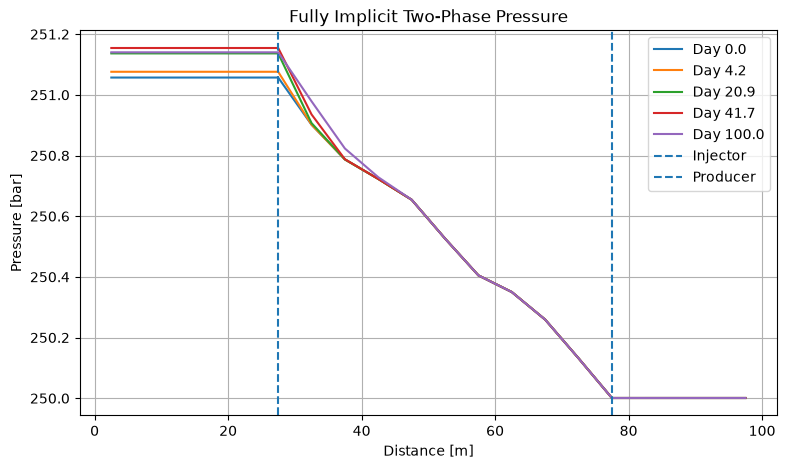

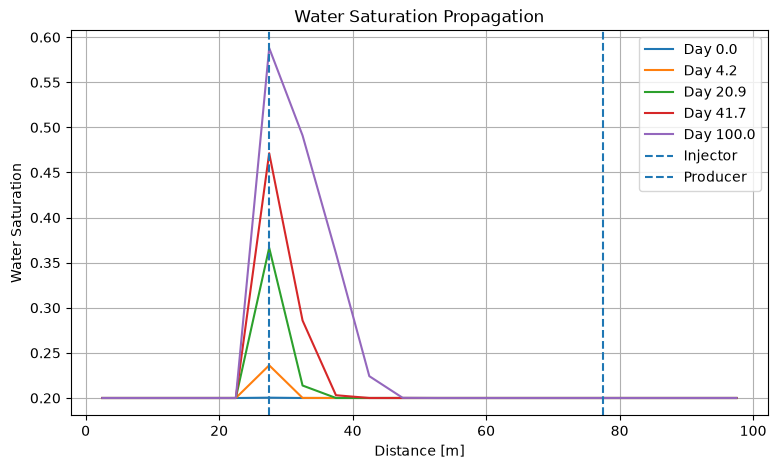

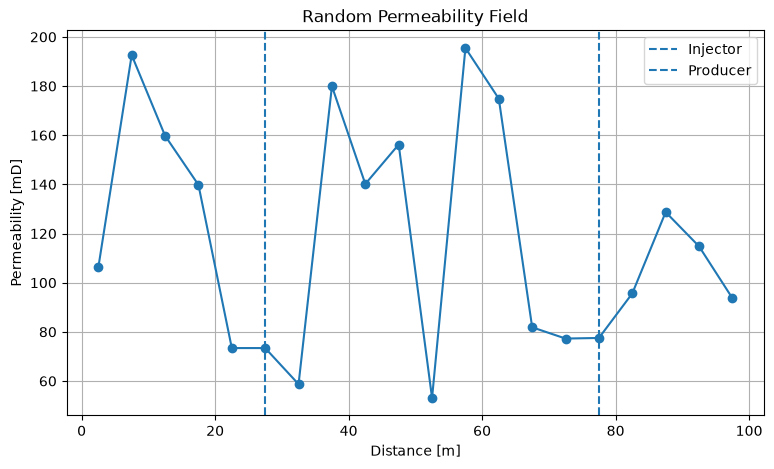

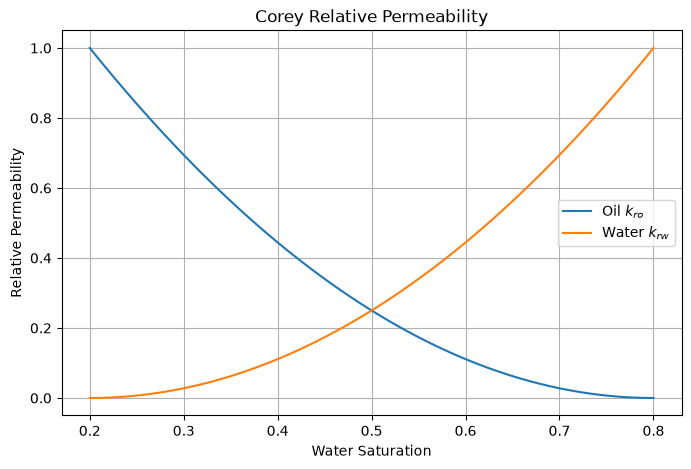

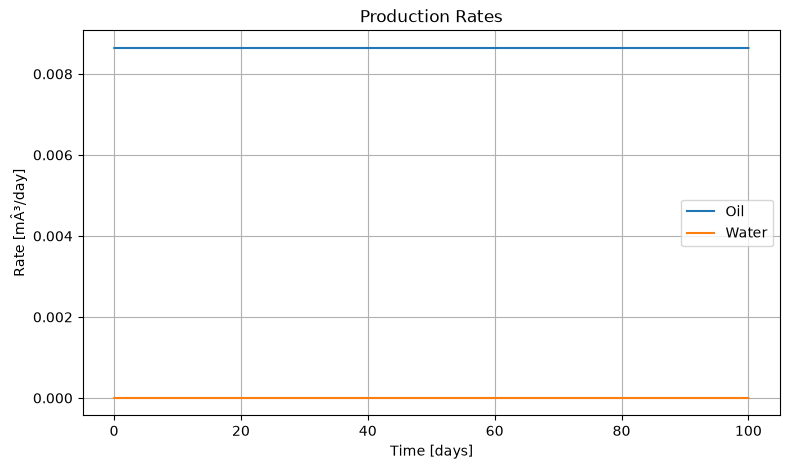

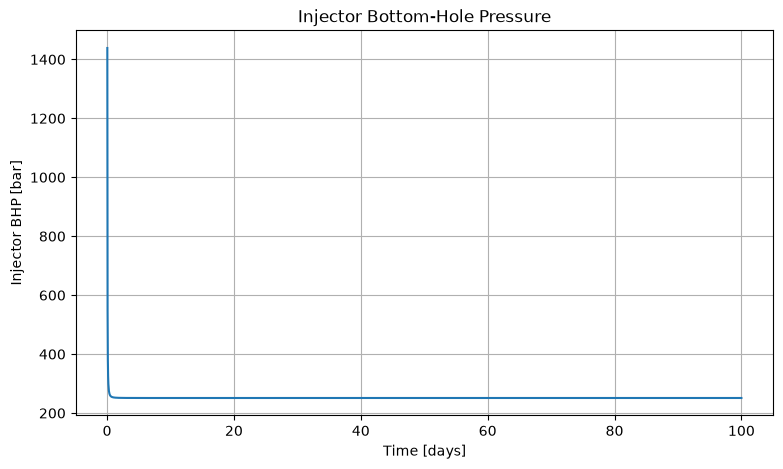


FINAL RESULTS
Injector cell       : 5
Injector location   : 27.50 m
Producer cell       : 15
Producer location   : 77.50 m
Final oil rate      : 0.008640 mÂ³/day
Final water rate    : 0.000000 mÂ³/day
Final injector BHP  : 251.14 bar
Final producer Sw   : 0.2000


In [2]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1D FULLY IMPLICIT TWO-PHASE OIL-WATER RESERVOIR
#
# Unknowns at each timestep:
#       p[0:N]        -> pressure [bar]
#       Sw[0:N]       -> water saturation
#
# Nonlinear system:
#
#       F(p_new, Sw_new) = 0
#
# solved using Newton-Raphson.
# ============================================================


# ============================================================
# 1. RESERVOIR PARAMETERS
# ============================================================

L = 100.0                     # reservoir length [m]
N = 20                        # number of cells
dx = L / N                    # cell length [m]

A = 1.0                       # cross-sectional area [mÂ²]
h = 10.0                      # reservoir thickness [m]

phi = 0.20                    # porosity

# Fluid viscosities
mu_w = 1e-3                   # water viscosity [Pa.s]
mu_o = 2e-3                   # oil viscosity [Pa.s]


# ============================================================
# 2. RANDOM PERMEABILITY
# ============================================================

np.random.seed(42)

# Random permeability [mD]
k_md = np.random.uniform(50, 200, N)

# Convert mD -> mÂ²
k = k_md * 9.869233e-16


# ============================================================
# 3. SATURATION PARAMETERS
# ============================================================

Swc = 0.20                    # connate water saturation
Sor = 0.20                    # residual oil saturation

# Initial water saturation
Sw_initial = np.ones(N) * Swc


# ============================================================
# 4. INITIAL PRESSURE
# ============================================================

p_initial_bar = 300.0        # [bar]

p_initial = np.ones(N) * p_initial_bar


# ============================================================
# 5. WELL LOCATIONS
# ============================================================

injector_cell = 5
producer_cell = 15

rw = 0.1                     # well radius [m]
skin = 0.0

# Injection rate
q_inj = 1e-7                 # [mÂ³/s]

# Producer bottom-hole pressure
p_wf_prod = 250e5            # 250 bar [Pa]


# ============================================================
# 6. TIME PARAMETERS
# ============================================================

dt = 3600.0                  # 1 hour [s]
n_steps = 2400               # 100 days


# ============================================================
# 7. GEOMETRIC TRANSMISSIBILITY
# ============================================================

# We separate permeability geometry from fluid mobility.
#
# q = T_geom * lambda * pressure_difference
#
# where:
#
# T_geom = k*A/dx
# lambda = kr/mu
#
# Harmonic averaging is used at cell interfaces.

T_geom = np.zeros(N - 1)

for i in range(N - 1):

    k_face = (
        2.0 * k[i] * k[i + 1]
        / (k[i] + k[i + 1])
    )

    T_geom[i] = (
        k_face * A / dx
    )


# ============================================================
# 8. WELL INDEX
# ============================================================

def geometric_well_index(k_cell, dx, h, rw, skin=0.0):

    """
    Geometric well index.

    Fluid mobility is NOT included here.

    q = GWI * lambda * (p_cell - p_wf)
    """

    re = 0.14 * dx

    GWI = (
        2.0 * np.pi * k_cell * h
        /
        (np.log(re / rw) + skin)
    )

    return GWI


GWI_inj = geometric_well_index(
    k[injector_cell],
    dx,
    h,
    rw,
    skin
)

GWI_prod = geometric_well_index(
    k[producer_cell],
    dx,
    h,
    rw,
    skin
)


# ============================================================
# 9. RELATIVE PERMEABILITY
# ============================================================

def relative_permeability(Sw):

    """
    Corey-type relative permeability model.
    """

    # Effective water saturation
    Se = (
        (Sw - Swc)
        /
        (1.0 - Swc - Sor)
    )

    # Keep in physical range
    Se = np.clip(Se, 0.0, 1.0)

    # Corey relationships
    krw = Se ** 2
    kro = (1.0 - Se) ** 2

    return kro, krw


# ============================================================
# 10. RESIDUAL FUNCTION
# ============================================================

def residual(x, Sw_old):

    """
    Construct fully implicit nonlinear residual.

    x contains:

        x[0:N]   -> pressure [bar]
        x[N:2N]  -> water saturation

    Returns:

        residual vector
        well information
    """

    # --------------------------------------------------------
    # Extract unknowns
    # --------------------------------------------------------

    p_bar = x[:N]
    Sw = x[N:]

    # Convert pressure bar -> Pa
    p = p_bar * 1e5


    # --------------------------------------------------------
    # Relative permeability
    # --------------------------------------------------------

    kro, krw = relative_permeability(Sw)

    # Mobility
    lambda_o = kro / mu_o
    lambda_w = krw / mu_w

    # Total mobility
    lambda_t = lambda_o + lambda_w


    # --------------------------------------------------------
    # Face fluxes
    # --------------------------------------------------------

    q_total_face = np.zeros(N - 1)
    q_water_face = np.zeros(N - 1)

    for i in range(N - 1):

        # Determine flow direction
        if p[i] >= p[i + 1]:
            upwind = i
        else:
            upwind = i + 1

        # Total mobility from upstream cell
        lambda_total_upwind = lambda_t[upwind]

        # Total flow rate
        q_total = (
            T_geom[i]
            * lambda_total_upwind
            * (p[i] - p[i + 1])
        )

        q_total_face[i] = q_total


        # Water fractional flow
        if lambda_t[upwind] > 0:

            fw = (
                lambda_w[upwind]
                / lambda_t[upwind]
            )

        else:

            fw = 0.0


        # Water flow
        q_water_face[i] = (
            fw * q_total
        )


    # ========================================================
    # WELL TERMS
    # ========================================================

    q_well_total = np.zeros(N)
    q_well_water = np.zeros(N)


    # --------------------------------------------------------
    # Injector
    # --------------------------------------------------------

    # Positive means flow INTO reservoir
    q_well_total[injector_cell] = q_inj
    q_well_water[injector_cell] = q_inj


    # --------------------------------------------------------
    # Producer
    # --------------------------------------------------------

    # Positive magnitude of production rate
    q_prod = (
        GWI_prod
        * lambda_t[producer_cell]
        *
        (
            p[producer_cell]
            - p_wf_prod
        )
    )

    # Producer is a sink in reservoir equations
    q_well_total[producer_cell] = -q_prod


    # Water fraction at producer
    if lambda_t[producer_cell] > 0:

        fw_prod = (
            lambda_w[producer_cell]
            /
            lambda_t[producer_cell]
        )

    else:

        fw_prod = 0.0


    q_water_prod = q_prod * fw_prod

    q_oil_prod = q_prod - q_water_prod

    q_well_water[producer_cell] = -q_water_prod


    # ========================================================
    # RESIDUALS
    # ========================================================

    R_pressure = np.zeros(N)
    R_water = np.zeros(N)


    # Pore volume per cell
    pore_volume = phi * A * dx


    for i in range(N):

        # ----------------------------------------------------
        # Total flow through faces
        # ----------------------------------------------------

        q_right = (
            q_total_face[i]
            if i < N - 1
            else 0.0
        )

        q_left = (
            q_total_face[i - 1]
            if i > 0
            else 0.0
        )


        # ----------------------------------------------------
        # PRESSURE / TOTAL-MASS BALANCE
        #
        # q_right - q_left - q_well = 0
        #
        # No accumulation here: incompressible two-phase model.
        # ----------------------------------------------------

        R_pressure[i] = (
            q_right
            - q_left
            - q_well_total[i]
        )


        # ----------------------------------------------------
        # WATER MASS BALANCE
        #
        # pore_volume * (Sw_new - Sw_old) / dt
        #
        # + water_out - water_in - water_source = 0
        # ----------------------------------------------------

        qw_right = (
            q_water_face[i]
            if i < N - 1
            else 0.0
        )

        qw_left = (
            q_water_face[i - 1]
            if i > 0
            else 0.0
        )


        accumulation = (
            pore_volume
            *
            (
                Sw[i] - Sw_old[i]
            )
            / dt
        )


        R_water[i] = (
            accumulation
            + qw_right
            - qw_left
            - q_well_water[i]
        )


    # ========================================================
    # SCALE RESIDUALS
    # ========================================================

    # Scaling keeps the Newton system numerically well-conditioned.

    q_scale = q_inj

    R_pressure /= q_scale
    R_water /= q_scale


    R = np.concatenate(
        [R_pressure, R_water]
    )


    # Return useful well information
    well_info = {
        "q_prod": q_prod,
        "q_water_prod": q_water_prod,
        "q_oil_prod": q_oil_prod,
    }


    return R, well_info


# ============================================================
# 11. NEWTON-RAPHSON SETTINGS
# ============================================================

max_newton_iterations = 20

newton_tolerance = 1e-7


# ============================================================
# 12. STORAGE FOR RESULTS
# ============================================================

pressure_history = []

saturation_history = []

oil_rate_history = []
water_rate_history = []

injector_bhp_history = []

time_history = []


# ============================================================
# 13. INITIAL STATE
# ============================================================

p_bar = p_initial.copy()
Sw = Sw_initial.copy()


# ============================================================
# 14. TIME LOOP
# ============================================================

for step in range(n_steps):

    print(
        f"Time step {step + 1}/{n_steps}"
    )


    # --------------------------------------------------------
    # Initial Newton guess
    #
    # Previous timestep state
    # --------------------------------------------------------

    x = np.concatenate(
        [p_bar, Sw]
    )


    # --------------------------------------------------------
    # Calculate initial residual
    # --------------------------------------------------------

    R, well_info = residual(
        x,
        Sw
    )


    converged = False


    # ========================================================
    # NEWTON ITERATIONS
    # ========================================================

    for iteration in range(
        max_newton_iterations
    ):

        residual_norm = np.max(
            np.abs(R)
        )

        print(
            f"    Newton {iteration + 1:2d}: "
            f"Residual = {residual_norm:.3e}"
        )


        # ----------------------------------------------------
        # Convergence
        # ----------------------------------------------------

        if residual_norm < newton_tolerance:

            converged = True
            break


        # ====================================================
        # NUMERICAL JACOBIAN
        # ====================================================

        n_unknowns = 2 * N

        J = np.zeros(
            (n_unknowns, n_unknowns)
        )


        for j in range(n_unknowns):

            # Pressure perturbation
            if j < N:

                epsilon = 1e-2       # 0.01 bar

            # Saturation perturbation
            else:

                epsilon = 1e-5


            x_perturbed = x.copy()

            x_perturbed[j] += epsilon


            # Calculate perturbed residual
            R_perturbed, _ = residual(
                x_perturbed,
                Sw
            )


            # Forward finite difference
            J[:, j] = (
                R_perturbed - R
            ) / epsilon


        # ====================================================
        # SOLVE NEWTON SYSTEM
        # ====================================================

        try:

            delta_x = np.linalg.solve(
                J,
                -R
            )

        except np.linalg.LinAlgError:

            raise RuntimeError(
                "Jacobian is singular. "
                "Newton iteration failed."
            )


        # ====================================================
        # BACKTRACKING LINE SEARCH
        # ====================================================

        alpha = 1.0

        current_norm = residual_norm

        accepted = False


        for _ in range(20):

            x_trial = (
                x
                + alpha * delta_x
            )


            # ------------------------------------------------
            # Check physical saturation bounds
            # ------------------------------------------------

            Sw_trial = x_trial[N:]


            if np.any(
                Sw_trial < Swc
            ):

                alpha *= 0.5
                continue


            if np.any(
                Sw_trial > 1.0 - Sor
            ):

                alpha *= 0.5
                continue


            # ------------------------------------------------
            # Trial residual
            # ------------------------------------------------

            R_trial, well_info_trial = residual(
                x_trial,
                Sw
            )


            trial_norm = np.max(
                np.abs(R_trial)
            )


            # ------------------------------------------------
            # Accept if residual decreases
            # ------------------------------------------------

            if trial_norm < current_norm:

                x = x_trial
                R = R_trial
                well_info = well_info_trial

                accepted = True

                break


            alpha *= 0.5


        # ----------------------------------------------------
        # Line search failure
        # ----------------------------------------------------

        if not accepted:

            raise RuntimeError(
                f"Newton line search failed "
                f"at timestep {step + 1}, "
                f"iteration {iteration + 1}"
            )


    # ========================================================
    # CHECK CONVERGENCE
    # ========================================================

    if not converged:

        raise RuntimeError(
            f"Newton did not converge "
            f"at timestep {step + 1}"
        )


    # ========================================================
    # UPDATE STATE
    # ========================================================

    p_bar = x[:N].copy()
    Sw = x[N:].copy()


    # ========================================================
    # INJECTOR BHP
    # ========================================================

    kro, krw = relative_permeability(Sw)

    lambda_w = krw / mu_w


    if lambda_w[injector_cell] > 0:

        # q = GWI * lambda_w * (pwf - pcell)
        p_wf_inj = (
            p_bar[injector_cell] * 1e5
            +
            q_inj
            /
            (
                GWI_inj
                * lambda_w[injector_cell]
            )
        )

        p_wf_inj_bar = p_wf_inj / 1e5

    else:

        p_wf_inj_bar = np.nan


    # ========================================================
    # STORE RESULTS
    # ========================================================

    pressure_history.append(
        p_bar.copy()
    )

    saturation_history.append(
        Sw.copy()
    )

    oil_rate_history.append(
        well_info["q_oil_prod"]
    )

    water_rate_history.append(
        well_info["q_water_prod"]
    )

    injector_bhp_history.append(
        p_wf_inj_bar
    )

    time_history.append(
        (step + 1) * dt / 86400.0
    )


# ============================================================
# 15. X COORDINATES
# ============================================================

x = np.linspace(
    dx / 2,
    L - dx / 2,
    N
)


# ============================================================
# 16. PRESSURE EVOLUTION
# ============================================================

plt.figure(figsize=(9, 5))

plot_steps = [
    0,
    100,
    500,
    1000,
    2399
]

for step in plot_steps:

    plt.plot(
        x,
        pressure_history[step],
        label=(
            f"Day "
            f"{time_history[step]:.1f}"
        )
    )


plt.axvline(
    x[injector_cell],
    linestyle="--",
    label="Injector"
)

plt.axvline(
    x[producer_cell],
    linestyle="--",
    label="Producer"
)

plt.xlabel("Distance [m]")
plt.ylabel("Pressure [bar]")
plt.title(
    "Fully Implicit Two-Phase Pressure"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 17. WATER SATURATION EVOLUTION
# ============================================================

plt.figure(figsize=(9, 5))

for step in plot_steps:

    plt.plot(
        x,
        saturation_history[step],
        label=(
            f"Day "
            f"{time_history[step]:.1f}"
        )
    )


plt.axvline(
    x[injector_cell],
    linestyle="--",
    label="Injector"
)

plt.axvline(
    x[producer_cell],
    linestyle="--",
    label="Producer"
)

plt.xlabel("Distance [m]")
plt.ylabel("Water Saturation")
plt.title(
    "Water Saturation Propagation"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 18. PERMEABILITY
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    k_md,
    marker="o"
)

plt.axvline(
    x[injector_cell],
    linestyle="--",
    label="Injector"
)

plt.axvline(
    x[producer_cell],
    linestyle="--",
    label="Producer"
)

plt.xlabel("Distance [m]")
plt.ylabel("Permeability [mD]")
plt.title(
    "Random Permeability Field"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 19. RELATIVE PERMEABILITY CURVES
# ============================================================

Sw_plot = np.linspace(
    Swc,
    1.0 - Sor,
    100
)

kro_plot, krw_plot = relative_permeability(
    Sw_plot
)

plt.figure(figsize=(8, 5))

plt.plot(
    Sw_plot,
    kro_plot,
    label="Oil $k_{ro}$"
)

plt.plot(
    Sw_plot,
    krw_plot,
    label="Water $k_{rw}$"
)

plt.xlabel("Water Saturation")
plt.ylabel("Relative Permeability")
plt.title(
    "Corey Relative Permeability"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 20. PRODUCTION RATES
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    time_history,
    np.array(oil_rate_history) * 86400,
    label="Oil"
)

plt.plot(
    time_history,
    np.array(water_rate_history) * 86400,
    label="Water"
)

plt.xlabel("Time [days]")
plt.ylabel("Rate [mÂ³/day]")
plt.title(
    "Production Rates"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 21. INJECTOR BHP
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    time_history,
    injector_bhp_history
)

plt.xlabel("Time [days]")
plt.ylabel("Injector BHP [bar]")
plt.title(
    "Injector Bottom-Hole Pressure"
)

plt.grid()

plt.show()


# ============================================================
# 22. FINAL RESULTS
# ============================================================

print("\n============================================")
print("FINAL RESULTS")
print("============================================")

print(
    f"Injector cell       : "
    f"{injector_cell}"
)

print(
    f"Injector location   : "
    f"{x[injector_cell]:.2f} m"
)

print(
    f"Producer cell       : "
    f"{producer_cell}"
)

print(
    f"Producer location   : "
    f"{x[producer_cell]:.2f} m"
)

print(
    f"Final oil rate      : "
    f"{oil_rate_history[-1] * 86400:.6f} mÂ³/day"
)

print(
    f"Final water rate    : "
    f"{water_rate_history[-1] * 86400:.6f} mÂ³/day"
)

print(
    f"Final injector BHP  : "
    f"{injector_bhp_history[-1]:.2f} bar"
)

print(
    f"Final producer Sw   : "
    f"{Sw[producer_cell]:.4f}"
)


Time step 1/240
  Newton  1 | Residual = 6.175e+04
  Newton  2 | Residual = 1.200e-04
  Newton  3 | Residual = 1.620e-08

Time step 2/240
  Newton  1 | Residual = 1.000e+00
  Newton  2 | Residual = 1.620e-08

Time step 3/240
  Newton  1 | Residual = 1.000e+00
  Newton  2 | Residual = 3.240e-08

Time step 4/240
  Newton  1 | Residual = 1.000e+00
  Newton  2 | Residual = 4.860e-08

Time step 5/240
  Newton  1 | Residual = 1.000e+00
  Newton  2 | Residual = 6.479e-08

Time step 6/240
  Newton  1 | Residual = 1.000e+00
  Newton  2 | Residual = 8.098e-08

Time step 7/240
  Newton  1 | Residual = 1.000e+00
  Newton  2 | Residual = 9.718e-08

Time step 8/240
  Newton  1 | Residual = 1.000e+00
  Newton  2 | Residual = 1.134e-07
  Newton  3 | Residual = 1.147e-10

Time step 9/240
  Newton  1 | Residual = 1.000e+00
  Newton  2 | Residual = 1.294e-07
  Newton  3 | Residual = 1.486e-10

Time step 10/240
  Newton  1 | Residual = 1.000e+00
  Newton  2 | Residual = 1.456e-07
  Newton  3 | Residual =

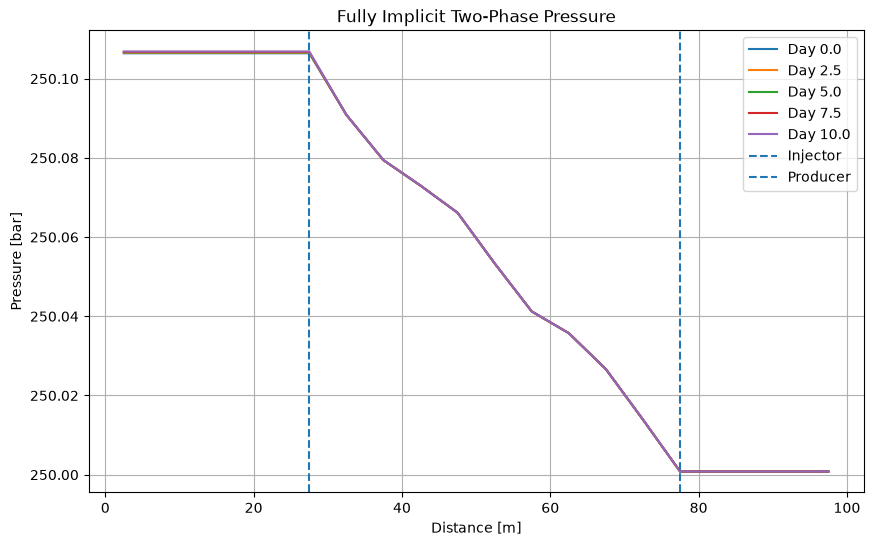

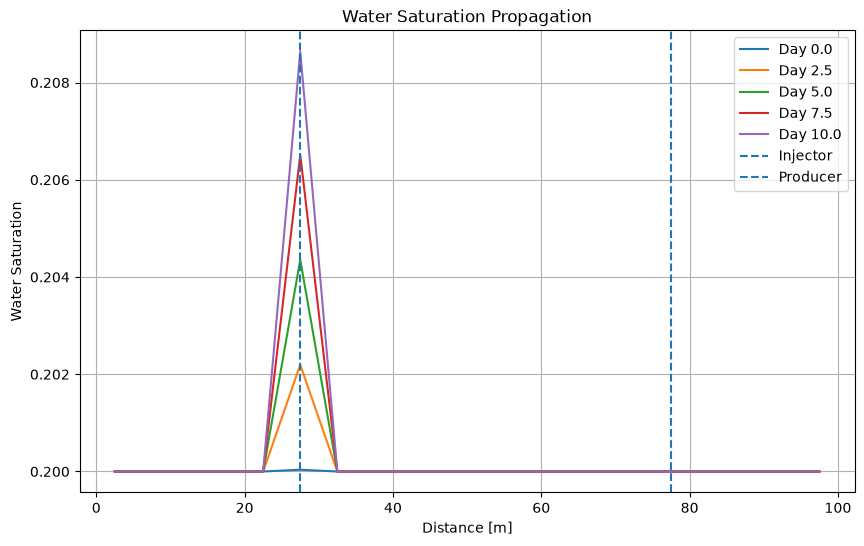

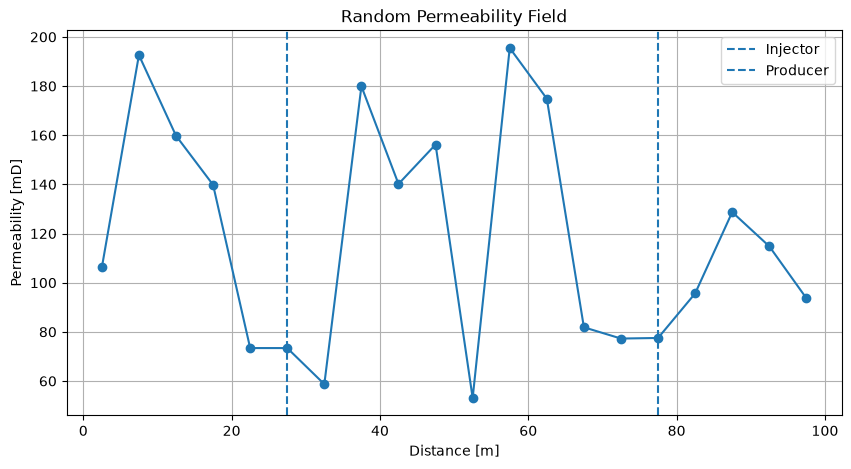

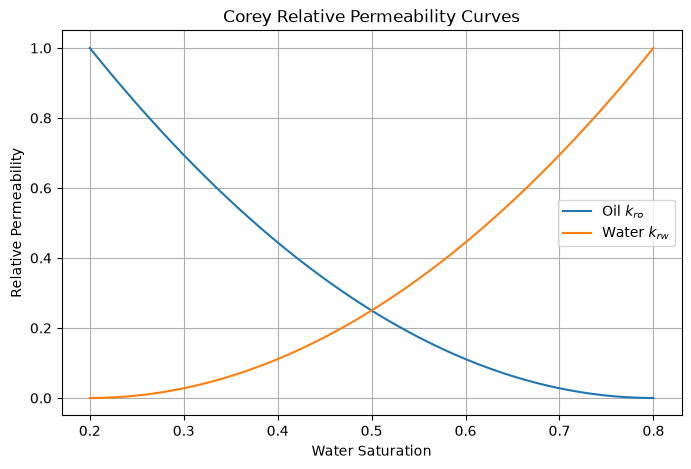

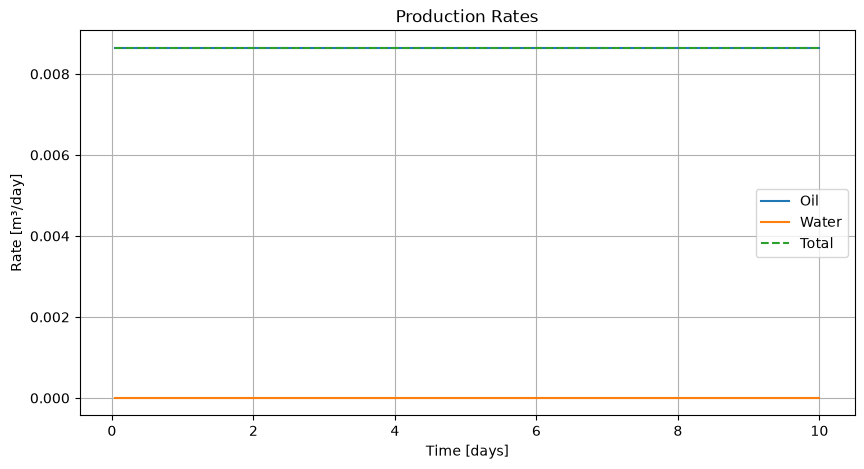

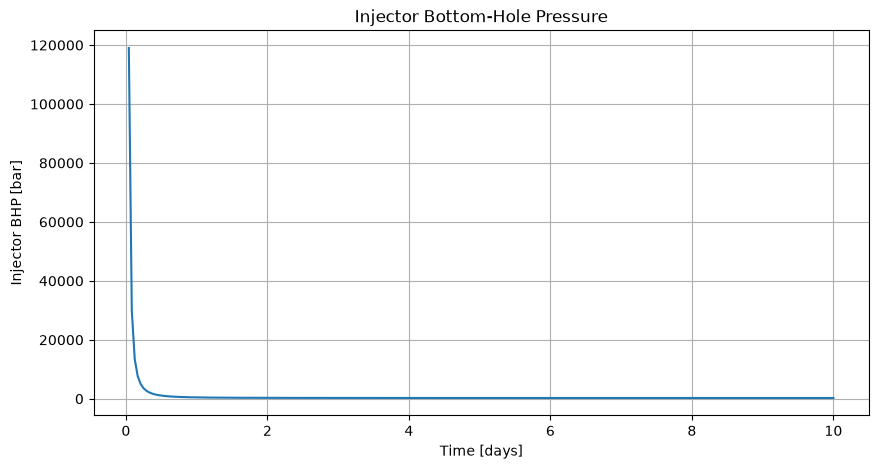

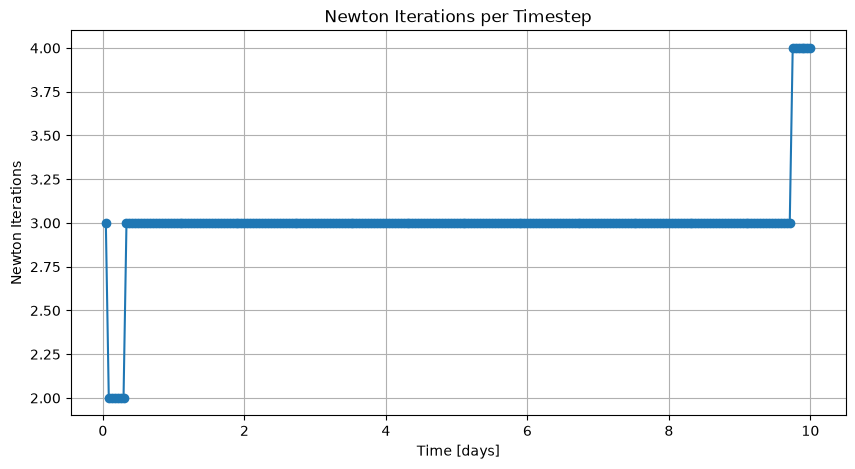

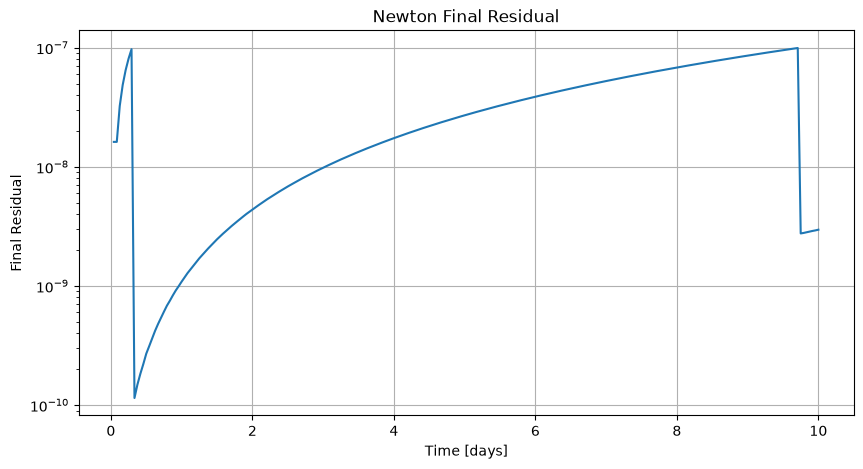

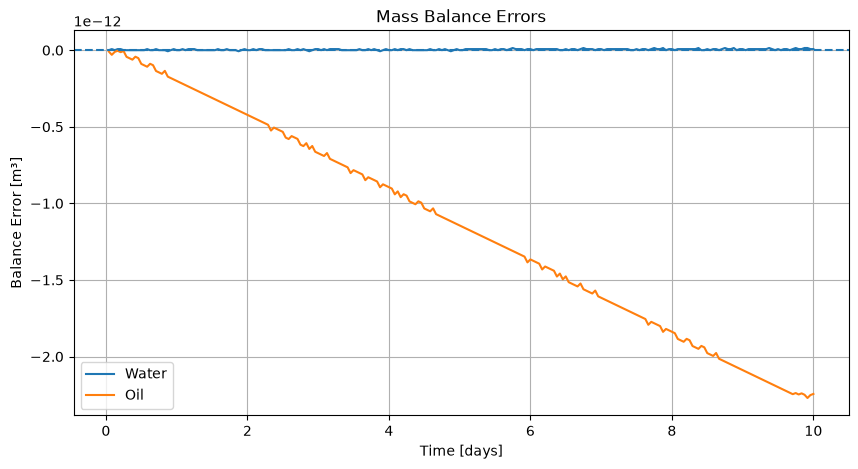

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1D FULLY IMPLICIT TWO-PHASE OIL-WATER RESERVOIR
#
# Unknowns at each timestep:
#
#       p[0:N]  -> pressure [bar]
#       Sw[0:N] -> water saturation
#
# Fully implicit nonlinear system:
#
#       F(p_new, Sw_new) = 0
#
# solved using Newton-Raphson.
# ============================================================


# ============================================================
# 1. RESERVOIR PARAMETERS
# ============================================================

L = 100.0                         # Reservoir length [m]
N = 20                            # Number of cells
dx = L / N                        # Cell length [m]

width = 1.0                       # Reservoir width [m]
h = 10.0                          # Reservoir thickness [m]

A = width * h                     # Cross-sectional area [m²]

phi = 0.20                        # Porosity


# ============================================================
# 2. FLUID PROPERTIES
# ============================================================

mu_w = 1e-3                       # Water viscosity [Pa.s]
mu_o = 2e-3                       # Oil viscosity [Pa.s]


# ============================================================
# 3. INITIAL SATURATION
# ============================================================

Swc = 0.20                        # Connate water saturation
Sor = 0.20                        # Residual oil saturation

Sw_initial = np.ones(N) * Swc


# ============================================================
# 4. INITIAL PRESSURE
# ============================================================

p_initial_bar = 300.0             # Initial pressure [bar]

p_initial = np.ones(N) * p_initial_bar


# ============================================================
# 5. RANDOM PERMEABILITY
# ============================================================

np.random.seed(42)

# Random permeability [mD]
k_md = np.random.uniform(50.0, 200.0, N)

# Convert mD -> m²
k = k_md * 9.869233e-16


# ============================================================
# 6. WELL LOCATIONS
# ============================================================

# Cell indices range from 0 to N-1

injector_cell = 5
producer_cell = 15

rw = 0.1                          # Well radius [m]
skin = 0.0


# ============================================================
# 7. WELL CONTROLS
# ============================================================

# Fixed water injection rate
q_inj = 1e-7                      # [m³/s]

# Producer is controlled by BHP
p_wf_prod = 250.0e5              # 250 bar [Pa]


# ============================================================
# 8. TIME
# ============================================================

dt = 3600.0                       # 1 hour [s]
n_steps = 240                     # 10 days

time_days = np.arange(
    1,
    n_steps + 1
) * dt / 86400.0


# ============================================================
# 9. GEOMETRIC TRANSMISSIBILITY
# ============================================================

# The geometric part of transmissibility is:
#
#     T_geom = k_face * A / dx
#
# Fluid mobility is applied later:
#
#     q = T_geom * lambda * dp
#
# Harmonic averaging is used at interfaces.

T_geom = np.zeros(N - 1)

for i in range(N - 1):

    k_face = (
        2.0
        * k[i]
        * k[i + 1]
        /
        (k[i] + k[i + 1])
    )

    T_geom[i] = (
        k_face
        * A
        / dx
    )


# ============================================================
# 10. WELL INDEX
# ============================================================

def well_index(k_cell, dx, h, rw, skin=0.0):
    """
    Peaceman-style geometric well index.

    Mobility is applied separately.

    q = GWI * lambda * (p_cell - p_wf)
    """

    re = 0.14 * dx

    GWI = (
        2.0
        * np.pi
        * k_cell
        * h
        /
        (
            np.log(re / rw)
            + skin
        )
    )

    return GWI


GWI_inj = well_index(
    k[injector_cell],
    dx,
    h,
    rw,
    skin
)

GWI_prod = well_index(
    k[producer_cell],
    dx,
    h,
    rw,
    skin
)


# ============================================================
# 11. RELATIVE PERMEABILITY
# ============================================================

def relative_permeability(Sw):
    """
    Corey-type relative permeability model.
    """

    # Effective water saturation
    Se = (
        (Sw - Swc)
        /
        (1.0 - Swc - Sor)
    )

    # Physical limits
    Se = np.clip(
        Se,
        0.0,
        1.0
    )

    # Corey equations
    krw = Se ** 2
    kro = (1.0 - Se) ** 2

    return kro, krw


# ============================================================
# 12. RESIDUAL FUNCTION
# ============================================================

def residual(x, Sw_old):
    """
    Fully implicit residual.

    x contains:

        x[0:N]   -> pressure [bar]
        x[N:2N]  -> water saturation

    Returns:

        R
        well information
    """

    # --------------------------------------------------------
    # Extract unknowns
    # --------------------------------------------------------

    p_bar = x[:N]
    Sw = x[N:]

    # Pressure [bar] -> [Pa]
    p = p_bar * 1e5


    # ========================================================
    # RELATIVE PERMEABILITY
    # ========================================================

    kro, krw = relative_permeability(Sw)

    # Mobility
    lambda_o = kro / mu_o
    lambda_w = krw / mu_w

    # Total mobility
    lambda_t = lambda_o + lambda_w


    # ========================================================
    # FACE FLUXES
    # ========================================================

    q_total_face = np.zeros(N - 1)
    q_water_face = np.zeros(N - 1)

    for i in range(N - 1):

        # ----------------------------------------------------
        # Upwind cell
        # ----------------------------------------------------

        if p[i] >= p[i + 1]:

            # Flow left -> right
            upwind = i

        else:

            # Flow right -> left
            upwind = i + 1


        # ----------------------------------------------------
        # Total mobility
        # ----------------------------------------------------

        lambda_upwind = lambda_t[upwind]


        # ----------------------------------------------------
        # Total flow
        # ----------------------------------------------------

        q_total = (
            T_geom[i]
            * lambda_upwind
            * (
                p[i]
                - p[i + 1]
            )
        )

        q_total_face[i] = q_total


        # ----------------------------------------------------
        # Water fractional flow
        # ----------------------------------------------------

        if lambda_t[upwind] > 0.0:

            fw = (
                lambda_w[upwind]
                /
                lambda_t[upwind]
            )

        else:

            fw = 0.0


        # ----------------------------------------------------
        # Water flow
        # ----------------------------------------------------

        q_water_face[i] = (
            fw
            * q_total
        )


    # ========================================================
    # WELL FLOWS
    # ========================================================

    q_well_total = np.zeros(N)
    q_well_water = np.zeros(N)


    # --------------------------------------------------------
    # INJECTOR
    # --------------------------------------------------------

    # Fixed-rate pure-water injection

    q_well_total[injector_cell] = q_inj

    q_well_water[injector_cell] = q_inj


    # --------------------------------------------------------
    # PRODUCER
    # --------------------------------------------------------

    # Production rate magnitude:
    #
    # q_prod = GWI * lambda_t *
    #          (p_cell - p_wf)

    q_prod = (
        GWI_prod
        * lambda_t[producer_cell]
        *
        (
            p[producer_cell]
            - p_wf_prod
        )
    )

    # Reservoir sign convention:
    #
    # positive = source
    # negative = sink

    q_well_total[producer_cell] = -q_prod


    # --------------------------------------------------------
    # Producer water fraction
    # --------------------------------------------------------

    if lambda_t[producer_cell] > 0.0:

        fw_prod = (
            lambda_w[producer_cell]
            /
            lambda_t[producer_cell]
        )

    else:

        fw_prod = 0.0


    # --------------------------------------------------------
    # Phase production
    # --------------------------------------------------------

    q_water_prod = (
        q_prod
        * fw_prod
    )

    q_oil_prod = (
        q_prod
        - q_water_prod
    )


    # Water source/sink
    q_well_water[producer_cell] = (
        -q_water_prod
    )


    # ========================================================
    # RESIDUALS
    # ========================================================

    R_pressure = np.zeros(N)
    R_water = np.zeros(N)


    # Pore volume
    pore_volume = (
        phi
        * A
        * dx
    )


    for i in range(N):

        # ----------------------------------------------------
        # TOTAL FLOW
        # ----------------------------------------------------

        if i < N - 1:

            q_right = q_total_face[i]

        else:

            # No-flow boundary
            q_right = 0.0


        if i > 0:

            q_left = q_total_face[i - 1]

        else:

            # No-flow boundary
            q_left = 0.0


        # ----------------------------------------------------
        # TOTAL MASS BALANCE
        #
        # outflow - inflow - source = 0
        # ----------------------------------------------------

        R_pressure[i] = (
            q_right
            - q_left
            - q_well_total[i]
        )


        # ----------------------------------------------------
        # WATER FLOW
        # ----------------------------------------------------

        if i < N - 1:

            qw_right = q_water_face[i]

        else:

            qw_right = 0.0


        if i > 0:

            qw_left = q_water_face[i - 1]

        else:

            qw_left = 0.0


        # ----------------------------------------------------
        # WATER ACCUMULATION
        # ----------------------------------------------------

        accumulation = (
            pore_volume
            *
            (
                Sw[i]
                - Sw_old[i]
            )
            /
            dt
        )


        # ----------------------------------------------------
        # WATER MASS BALANCE
        # ----------------------------------------------------

        R_water[i] = (
            accumulation
            + qw_right
            - qw_left
            - q_well_water[i]
        )


    # ========================================================
    # RESIDUAL SCALING
    # ========================================================

    q_scale = q_inj

    R_pressure /= q_scale
    R_water /= q_scale


    # Combine
    R = np.concatenate(
        [
            R_pressure,
            R_water
        ]
    )


    # ========================================================
    # WELL INFORMATION
    # ========================================================

    well_info = {

        "q_prod": q_prod,

        "q_water_prod": q_water_prod,

        "q_oil_prod": q_oil_prod,

        "fw_prod": fw_prod
    }


    return R, well_info


# ============================================================
# 13. NEWTON SETTINGS
# ============================================================

max_newton_iterations = 15

newton_tolerance = 1e-7

pressure_epsilon = 1e-2       # 0.01 bar
saturation_epsilon = 1e-5


# ============================================================
# 14. RESULT STORAGE
# ============================================================

pressure_history = []

saturation_history = []

oil_rate_history = []

water_rate_history = []

total_production_history = []

injector_bhp_history = []

newton_iterations_history = []

newton_residual_history = []

time_history = []


# ============================================================
# 15. INITIAL STATE
# ============================================================

p_bar = p_initial.copy()

Sw = Sw_initial.copy()


# ============================================================
# 16. TIME LOOP
# ============================================================

for step in range(n_steps):

    print(
        f"\nTime step "
        f"{step + 1}/{n_steps}"
    )


    # --------------------------------------------------------
    # Previous timestep saturation
    # --------------------------------------------------------

    Sw_old = Sw.copy()


    # --------------------------------------------------------
    # Initial Newton guess
    # --------------------------------------------------------

    x = np.concatenate(
        [
            p_bar,
            Sw
        ]
    )


    # --------------------------------------------------------
    # Initial residual
    # --------------------------------------------------------

    R, well_info = residual(
        x,
        Sw_old
    )


    converged = False


    # ========================================================
    # NEWTON ITERATIONS
    # ========================================================

    for iteration in range(
        max_newton_iterations
    ):

        residual_norm = np.max(
            np.abs(R)
        )


        print(
            f"  Newton {iteration + 1:2d}"
            f" | Residual = "
            f"{residual_norm:.3e}"
        )


        # ----------------------------------------------------
        # Convergence
        # ----------------------------------------------------

        if residual_norm < newton_tolerance:

            converged = True

            break


        # ====================================================
        # NUMERICAL JACOBIAN
        # ====================================================

        n_unknowns = 2 * N

        J = np.zeros(
            (n_unknowns, n_unknowns)
        )


        for j in range(n_unknowns):

            # ------------------------------------------------
            # Perturb pressure
            # ------------------------------------------------

            if j < N:

                epsilon = pressure_epsilon

            # ------------------------------------------------
            # Perturb saturation
            # ------------------------------------------------

            else:

                epsilon = saturation_epsilon


            x_perturbed = x.copy()

            x_perturbed[j] += epsilon


            # ------------------------------------------------
            # Perturbed residual
            # ------------------------------------------------

            R_perturbed, _ = residual(
                x_perturbed,
                Sw_old
            )


            # ------------------------------------------------
            # Finite-difference derivative
            # ------------------------------------------------

            J[:, j] = (
                R_perturbed
                - R
            ) / epsilon


        # ====================================================
        # NEWTON STEP
        # ====================================================

        try:

            delta_x = np.linalg.solve(
                J,
                -R
            )

        except np.linalg.LinAlgError:

            raise RuntimeError(
                "Jacobian is singular."
            )


        # ====================================================
        # BACKTRACKING LINE SEARCH
        # ====================================================

        alpha = 1.0

        current_norm = residual_norm

        accepted = False


        for _ in range(20):

            x_trial = (
                x
                +
                alpha * delta_x
            )


            # ------------------------------------------------
            # Check saturation
            # ------------------------------------------------

            Sw_trial = x_trial[N:]


            if np.any(
                Sw_trial < Swc
            ):

                alpha *= 0.5

                continue


            if np.any(
                Sw_trial > 1.0 - Sor
            ):

                alpha *= 0.5

                continue


            # ------------------------------------------------
            # Evaluate trial residual
            # ------------------------------------------------

            R_trial, well_info_trial = residual(
                x_trial,
                Sw_old
            )


            trial_norm = np.max(
                np.abs(R_trial)
            )


            # ------------------------------------------------
            # Accept step if residual decreases
            # ------------------------------------------------

            if trial_norm < current_norm:

                x = x_trial

                R = R_trial

                well_info = (
                    well_info_trial
                )

                accepted = True

                break


            alpha *= 0.5


        # ----------------------------------------------------
        # Line search failure
        # ----------------------------------------------------

        if not accepted:

            raise RuntimeError(
                f"Line search failed at "
                f"timestep {step + 1}, "
                f"Newton iteration "
                f"{iteration + 1}"
            )


    # ========================================================
    # CONVERGENCE CHECK
    # ========================================================

    if not converged:

        raise RuntimeError(
            f"Newton did not converge "
            f"at timestep {step + 1}"
        )


    # ========================================================
    # UPDATE STATE
    # ========================================================

    p_bar = x[:N].copy()

    Sw = x[N:].copy()


    # ========================================================
    # FINAL RESIDUAL
    # ========================================================

    final_residual = np.max(
        np.abs(R)
    )


    # ========================================================
    # NEWTON DIAGNOSTICS
    # ========================================================

    newton_iterations_history.append(
        iteration + 1
    )

    newton_residual_history.append(
        final_residual
    )


    # ========================================================
    # INJECTOR BHP
    # ========================================================

    kro, krw = relative_permeability(
        Sw
    )

    lambda_w = krw / mu_w


    if lambda_w[injector_cell] > 0:

        p_wf_inj = (
            p_bar[injector_cell] * 1e5
            +
            q_inj
            /
            (
                GWI_inj
                * lambda_w[injector_cell]
            )
        )

        p_wf_inj_bar = (
            p_wf_inj / 1e5
        )

    else:

        p_wf_inj_bar = np.nan


    # ========================================================
    # STORE RESULTS
    # ========================================================

    pressure_history.append(
        p_bar.copy()
    )

    saturation_history.append(
        Sw.copy()
    )

    oil_rate_history.append(
        well_info["q_oil_prod"]
    )

    water_rate_history.append(
        well_info["q_water_prod"]
    )

    total_production_history.append(
        well_info["q_prod"]
    )

    injector_bhp_history.append(
        p_wf_inj_bar
    )

    time_history.append(
        (step + 1)
        * dt
        / 86400.0
    )


# ============================================================
# 17. CONVERT RESULTS TO ARRAYS
# ============================================================

pressure_history = np.array(
    pressure_history
)

saturation_history = np.array(
    saturation_history
)

oil_rate_history = np.array(
    oil_rate_history
)

water_rate_history = np.array(
    water_rate_history
)

total_production_history = np.array(
    total_production_history
)

injector_bhp_history = np.array(
    injector_bhp_history
)

newton_iterations_history = np.array(
    newton_iterations_history
)

newton_residual_history = np.array(
    newton_residual_history
)

time_history = np.array(
    time_history
)


# ============================================================
# 18. X COORDINATES
# ============================================================

x = (
    np.arange(N)
    * dx
    + dx / 2.0
)


# ============================================================
# 19. VALIDATION
# ============================================================

print("\n")
print("============================================================")
print("SOLVER VALIDATION")
print("============================================================")


# ============================================================
# A. NEWTON CONVERGENCE
# ============================================================

print("\n[1] Newton convergence")

print(
    "Maximum Newton iterations:",
    newton_iterations_history.max()
)

print(
    "Mean Newton iterations:",
    newton_iterations_history.mean()
)

print(
    "Maximum final residual:",
    f"{newton_residual_history.max():.3e}"
)

if np.all(
    newton_residual_history
    < newton_tolerance
):

    print("Newton convergence: PASS")

else:

    print("Newton convergence: FAIL")


# ============================================================
# B. SATURATION BOUNDS
# ============================================================

print("\n[2] Saturation bounds")

min_Sw = saturation_history.min()
max_Sw = saturation_history.max()

print(
    f"Minimum Sw: {min_Sw:.6f}"
)

print(
    f"Maximum Sw: {max_Sw:.6f}"
)

if (
    min_Sw >= Swc - 1e-10
    and
    max_Sw <= 1.0 - Sor + 1e-10
):

    print("Saturation bounds: PASS")

else:

    print("Saturation bounds: FAIL")


# ============================================================
# C. GLOBAL FLOW BALANCE
# ============================================================

print("\n[3] Global flow balance")

# Total production = oil + water
q_prod_total = (
    oil_rate_history
    +
    water_rate_history
)

flow_imbalance = (
    q_inj
    -
    q_prod_total
)

relative_flow_error = (
    np.abs(flow_imbalance)
    /
    q_inj
)

print(
    "Maximum absolute flow imbalance:",
    f"{np.max(np.abs(flow_imbalance)):.6e}",
    "m³/s"
)

print(
    "Maximum relative flow imbalance:",
    f"{relative_flow_error.max():.6e}"
)


# ============================================================
# D. WATER BALANCE
# ============================================================

print("\n[4] Water balance")

pore_volume = (
    phi
    * A
    * dx
)


# Initial water volume
Vw_initial = (
    np.sum(Sw_initial)
    * pore_volume
)


# Cumulative injected water
Vw_injected = (
    q_inj
    * time_history
    * 86400.0
)


# Remaining water
Vw_remaining = np.sum(
    saturation_history,
    axis=1
) * pore_volume


# Produced water
Vw_produced = (
    np.cumsum(
        water_rate_history
    )
    * dt
)


# Water balance error
water_balance_error = (
    Vw_initial
    +
    Vw_injected
    -
    Vw_remaining
    -
    Vw_produced
)

print(
    "Maximum water balance error:",
    f"{np.max(np.abs(water_balance_error)):.6e}",
    "m³"
)


# ============================================================
# E. OIL BALANCE
# ============================================================

print("\n[5] Oil balance")


# Initial oil
So_initial = (
    1.0
    - Sw_initial
)

Vo_initial = (
    np.sum(So_initial)
    * pore_volume
)


# Remaining oil
Vo_remaining = np.sum(
    1.0 - saturation_history,
    axis=1
) * pore_volume


# Produced oil
Vo_produced = (
    np.cumsum(
        oil_rate_history
    )
    * dt
)


# Oil balance
oil_balance_error = (
    Vo_initial
    -
    Vo_remaining
    -
    Vo_produced
)

print(
    "Maximum oil balance error:",
    f"{np.max(np.abs(oil_balance_error)):.6e}",
    "m³"
)


# ============================================================
# F. OIL RECOVERY
# ============================================================

oil_recovery = (
    Vo_produced[-1]
    /
    Vo_initial
)

print("\n[6] Recovery")

print(
    f"Initial oil volume: "
    f"{Vo_initial:.6f} m³"
)

print(
    f"Produced oil: "
    f"{Vo_produced[-1]:.6f} m³"
)

print(
    f"Remaining oil: "
    f"{Vo_remaining[-1]:.6f} m³"
)

print(
    f"Oil recovery: "
    f"{oil_recovery * 100:.3f}%"
)


# ============================================================
# 20. PRESSURE EVOLUTION
# ============================================================

plt.figure(figsize=(10, 6))

plot_indices = [
    0,
    n_steps // 4,
    n_steps // 2,
    3 * n_steps // 4,
    n_steps - 1
]

for idx in plot_indices:

    plt.plot(
        x,
        pressure_history[idx],
        label=(
            f"Day "
            f"{time_history[idx]:.1f}"
        )
    )


plt.axvline(
    x[injector_cell],
    linestyle="--",
    label="Injector"
)

plt.axvline(
    x[producer_cell],
    linestyle="--",
    label="Producer"
)

plt.xlabel("Distance [m]")
plt.ylabel("Pressure [bar]")
plt.title(
    "Fully Implicit Two-Phase Pressure"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 21. WATER SATURATION EVOLUTION
# ============================================================

plt.figure(figsize=(10, 6))

for idx in plot_indices:

    plt.plot(
        x,
        saturation_history[idx],
        label=(
            f"Day "
            f"{time_history[idx]:.1f}"
        )
    )


plt.axvline(
    x[injector_cell],
    linestyle="--",
    label="Injector"
)

plt.axvline(
    x[producer_cell],
    linestyle="--",
    label="Producer"
)

plt.xlabel("Distance [m]")
plt.ylabel("Water Saturation")
plt.title(
    "Water Saturation Propagation"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 22. PERMEABILITY
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    x,
    k_md,
    marker="o"
)

plt.axvline(
    x[injector_cell],
    linestyle="--",
    label="Injector"
)

plt.axvline(
    x[producer_cell],
    linestyle="--",
    label="Producer"
)

plt.xlabel("Distance [m]")
plt.ylabel("Permeability [mD]")
plt.title(
    "Random Permeability Field"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 23. RELATIVE PERMEABILITY
# ============================================================

Sw_plot = np.linspace(
    Swc,
    1.0 - Sor,
    200
)

kro_plot, krw_plot = (
    relative_permeability(
        Sw_plot
    )
)

plt.figure(figsize=(8, 5))

plt.plot(
    Sw_plot,
    kro_plot,
    label="Oil $k_{ro}$"
)

plt.plot(
    Sw_plot,
    krw_plot,
    label="Water $k_{rw}$"
)

plt.xlabel("Water Saturation")
plt.ylabel("Relative Permeability")
plt.title(
    "Corey Relative Permeability Curves"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 24. PRODUCTION RATES
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    time_history,
    oil_rate_history * 86400.0,
    label="Oil"
)

plt.plot(
    time_history,
    water_rate_history * 86400.0,
    label="Water"
)

plt.plot(
    time_history,
    total_production_history * 86400.0,
    linestyle="--",
    label="Total"
)

plt.xlabel("Time [days]")
plt.ylabel("Rate [m³/day]")
plt.title(
    "Production Rates"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 25. INJECTOR BHP
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    time_history,
    injector_bhp_history
)

plt.xlabel("Time [days]")
plt.ylabel("Injector BHP [bar]")
plt.title(
    "Injector Bottom-Hole Pressure"
)

plt.grid()

plt.show()


# ============================================================
# 26. NEWTON ITERATION HISTORY
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    time_history,
    newton_iterations_history,
    marker="o"
)

plt.xlabel("Time [days]")
plt.ylabel("Newton Iterations")
plt.title(
    "Newton Iterations per Timestep"
)

plt.grid()

plt.show()


# ============================================================
# 27. NEWTON RESIDUAL HISTORY
# ============================================================

plt.figure(figsize=(10, 5))

plt.semilogy(
    time_history,
    newton_residual_history
)

plt.xlabel("Time [days]")
plt.ylabel("Final Residual")
plt.title(
    "Newton Final Residual"
)

plt.grid()

plt.show()


# ============================================================
# 28. MASS BALANCE PLOTS
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    time_history,
    water_balance_error,
    label="Water"
)

plt.plot(
    time_history,
    oil_balance_error,
    label="Oil"
)

plt.axhline(
    0.0,
    linestyle="--"
)

plt.xlabel("Time [days]")
plt.ylabel("Balance Error [m³]")
plt.title(
    "Mass Balance Errors"
)

plt.legend()
plt.grid()

plt.show()